## Question-Specific EDA

The questions that will be prepared for this section of the EDA are as follows:

1. What behavioral events or sequence of events are the strongest predictors of cart abandonment?
    1. Define: Events or sequences of clicks, page visits, or time delays that most commonly lead to cart abandonment.
    2. Measure: Frequency and type of events before abandonment across sessions.
2. What behaviors or conditions lead to a customer returning to complete a previously abandoned cart?
    1. Define: Recovery = Completed checkout after initial cart abandonment within X days.
    2. Measure: Recovery rate by user behavior / device.

First, we need to *define* cart abandonment and set up a way to *identify* it in the data. 

Definition of cart abandonment: In the context of our data, cart abandonment is defined a process following the steps below 
1. In the EVENT_NAME column of the google analytics dataset, 'added_to_cart' is created
2. No 'purchased' event is created by the nearest cutoff time from the CUTOFF_TIMES dataset.
3. Customer_ID is used to delineate which events correlate with the correct cutoff times

Therefore, we need to extract an "abandoned" dataset from the the originial dataset, showing when tables were abandoned vs not.

To identify material data, we will take the dimentionality reductions and datatype adjustments recommended above, to keep the analysis concise and material to a majority of Swire's operations. 

# Table Prep 

## Step 1: Import packages

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
pd.set_option('display.max_rows', 10000)   

## Step 2: Import Data and Create Column Name Dictionary

In [104]:
# Google anaytics
GoogleAnalytics = pd.read_csv("clean_GA.csv")
# orders
orders = pd.read_csv("clean_orders.csv")
# sales 
sales = pd.read_csv("clean_sales.csv")
# material
material = pd.read_csv("clean_material.csv")
# customer
customer = pd.read_csv("clean_customer.csv")
# custoff_times
cutoff_times = pd.read_csv("clean_cutoff_times.csv")
# operating hours
operating_hours = pd.read_csv("clean_operating_hours.csv")
# visit plan
#visit_plan = pd.read_csv("clean_visit_plan.csv", low_memory=False)

In [105]:
ColumnNames = {
    "GoogleAnalytics": GoogleAnalytics.columns.tolist(),
    "orders": orders.columns.tolist(),
    "sales": sales.columns.tolist(),
    "material": material.columns.tolist(),
    "customer": customer.columns.tolist(),
    "cutoff_times": cutoff_times.columns.tolist(),
    "operating_hours": operating_hours.columns.tolist()
    #"visit_plan": visit_plan.columns.tolist()
}

for key in ColumnNames:
    print(f"DataFrame: {key}")
    print(ColumnNames[key])

DataFrame: GoogleAnalytics
['customer_id', 'event_name', 'device_category', 'device_mobile_brand_name', 'device_operating_system', 'event_page_name', 'event_page_title', 'items', 'event_date', 'event_ts_utc', 'abandoned', 'purchase_segment', 'False_by_purchase', 'recovered']
DataFrame: orders
['customer_id', 'material_id', 'sales_office_id', 'order_quantity', 'order_type', 'created_ts_utc', 'order_quarter_start']
DataFrame: sales
['customer_id', 'material_id', 'physical_volume', 'unit_price', 'revenue', 'profit', 'posting_date', 'posting_ts', 'quarter_start']
DataFrame: material
['material_id', 'trademark', 'flavor', 'beverage_category', 'packaging_type', 'packaging_size']
DataFrame: customer
['customer_id', 'sales_office_id', 'sales_office_location', 'cold_drink_channel_description', 'customer_sub_trade_channel_description', 'distribution_mode', 'shipping_duration', 'shipping_destination']
DataFrame: cutoff_times
['sales_office_id', 'sales_office_location', 'shipping_duration', 'cutof

## Prep Cart Abandonment Table for Modeling

In [106]:
GoogleAnalytics.head(n=5)

,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,items,event_date,event_ts_utc,abandoned,purchase_segment,False_by_purchase,recovered
0,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2024-06-13,2024-06-13 04:43:59.908000+00:00,False,500245685.5,no purchase,not applicable
1,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2024-06-13,2024-06-13 04:43:59.908000+00:00,False,500245685.5,no purchase,not applicable
2,500245685,nav_link_click,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2024-06-13,2024-06-13 04:44:27.635000+00:00,False,500245685.5,no purchase,not applicable
3,500245685,page_view,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2024-06-13,2024-06-13 04:44:27.635000+00:00,False,500245685.5,no purchase,not applicable
4,500245685,page_view,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2024-06-13,2024-06-13 04:44:27.635000+00:00,False,500245685.5,no purchase,not applicable


In [107]:
GoogleAnalytics.dtypes

customer_id                   int64
event_name                   object
device_category              object
device_mobile_brand_name     object
device_operating_system      object
event_page_name              object
event_page_title             object
items                        object
event_date                   object
event_ts_utc                 object
abandoned                    object
purchase_segment            float64
False_by_purchase            object
recovered                    object
dtype: object

In [108]:
# Convert the date/datetime(s)

GoogleAnalytics['event_date'] = pd.to_datetime(GoogleAnalytics['event_date'])
GoogleAnalytics['event_ts_utc'] = pd.to_datetime(GoogleAnalytics['event_ts_utc'],format='ISO8601', utc=True)

# Check
print(GoogleAnalytics.dtypes)

customer_id                               int64
event_name                               object
device_category                          object
device_mobile_brand_name                 object
device_operating_system                  object
event_page_name                          object
event_page_title                         object
items                                    object
event_date                       datetime64[ns]
event_ts_utc                datetime64[ns, UTC]
abandoned                                object
purchase_segment                        float64
False_by_purchase                        object
recovered                                object
dtype: object


In [109]:
print("There are",GoogleAnalytics.index.size,"rows in the dataframe.")
print("There are",GoogleAnalytics.columns.size,"columns in the dataframe.")

There are 3704088 rows in the dataframe.
There are 14 columns in the dataframe.


In [110]:
GoogleAnalytics.shape

(3704088, 14)

Check that there are no abandoned rows for purchase

In [111]:
count = GoogleAnalytics.query("event_name == 'purchase' and abandoned == True").shape[0]
print(count)

0


There are no cells with with purchase and an abandoned cart

In [112]:
GoogleAnalytics['abandoned'].isna().sum()

28514

In [113]:
GoogleAnalytics = GoogleAnalytics.dropna(subset=['abandoned'])

# Modeling

1. What behavioral events or sequence of events are the strongest predictors of cart abandonment?
    1. Define: Events or sequences of clicks, page visits, or time delays that most commonly lead to cart abandonment.
    2. Measure: Frequency and type of events before abandonment across sessions.
2. What behaviors or conditions lead to a customer returning to complete a previously abandoned cart?
    1. Define: Recovery = Completed checkout after initial cart abandonment within X days.
    2. Measure: Recovery rate by user behavior / device.

## Results

1. What behavioral events or sequence of events are the strongest predictors of cart abandonment?\
    25.92% of all abandoned carts have the last click as 'update_cart' \
    8.03% of all abandoned carts have the last click as 'remove_from_cart' \
    7.45% of all abandoned carts have the last click as 'view_item_list'\
    6.92% of all abandoned carts have the last click as 'page_view - Unknown Page'\
    5.7% of all abandoned carts have the last click as 'page_view - Mycoke Dashboard'\    
    5.7% of all abandoned carts have the last click as 'user_engagement'\
    5.45% of all abandoned carts have the last click as 'button_click - Mycoke Orders - Cart'\
    4.29% of all abandoned carts have the last click as 'page_view - Mycoke Orders'\
    3.18% of all abandoned carts have the last click as 'button_click - Mycoke Orders - Checkout: Review Order'\
    3.18% of all abandoned carts have the last click as 'proceed_to_checkout'\
    75.82% of all abandoned carts ended with the 10 afformentioned events. 
    
    Please refer to the chart in the sequence mining section below to see which event_names correlate with a 75% chance of purcase within one day of happening. We can potentially reduce cart abandonment by 70.0 percent if we reach out to customers within one day of entering any of the events where a purchase occurs one day from the event (on average).\
    Please refer to the chart in the sequence mining section below to see which event_names correlate with a 85% chance of purcase within one day of happening. We can potentially reduce cart abandonment by 46.0 percent if we reach out to customers within one day of entering any of the events where a purchase occurs one day from the event (on average).
    
    Recommendation: reach out to customers within 1 day of entering any of these events if a purchase has not followed yet. 
          
    
    create a customer profile for these results.
\
    
2. What behaviors or conditions lead to a customer returning to complete a previously abandoned cart?

    50% of carts are recovered in 2 hours.
    65% of carts are recovered in 3 days.
    75% of carts are recovered in 168 hours, or 7 days.
    80% of carts are recovered in 235 hours, or 10 days.
    90% of carts are recovered in 674 hours, or 28 days. 
    
    As we can see from the sequence mining results below, there isn't much insight we can gather. The results are similar in value as the abandonment results, except even in the last event section, 92% are purchases, which makes sense. We should focus on understanding time as a factor for cart recovery, as it appears to be a strong indicator of whether a cart will be recovered in a timely fashion or not. It appears that the steep drop off in reovery over time shows that abandonment is intentional. Customers either return to their carts, or they move on and wait until they need inventory. 
    
    As far as device correlation with abandoment goes, the ratios of desktop, mobile, and tablet are nearly identical in abandoned and recovered carts. No major insights or actions can be taken from device type. Any ML model would have insufficient signal to train on.
    
    
3. Overall, there is a 53.71% recovery rate. We could boost this to ~90%+ recovery with the recommendations above.
    

## Sequence Mining for Cart Abandonment

### Check Unknown Page Error Rate

We discovered during the EDA that there was an Unknown Page event name. I had a hunch that it correlated with an event title of error. Let's see if it does.

In [114]:
GoogleAnalyticsCheck = GoogleAnalytics[(GoogleAnalytics['event_page_title'] == 'Error')]

event_page_name
Unknown Page                                  0.910612
Mycoke Orders                                 0.041887
Mycoke Orders - Product:                      0.014682
Mycoke Product List - Category:               0.011443
Mycoke Orders - Cart                          0.006261
Mycoke Invoices                               0.005074
Mycoke Dashboard                              0.004102
Mycoke Account Profile                        0.002159
Mycoke Support History - Customer Services    0.001943
Mycoke Account Accounts                       0.001295
Public About Mycoke                           0.000432
Mycoke Account Users                          0.000108
Name: proportion, dtype: float64


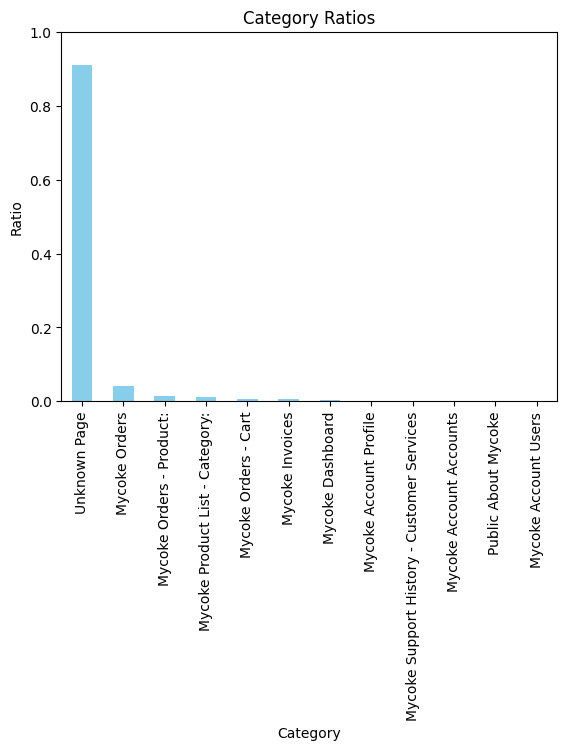

In [115]:
# Step 1: Compute ratios
ratios = GoogleAnalyticsCheck['event_page_name'].value_counts(normalize=True)
print(ratios)

# Step 2: Plot as bar chart
ratios.plot(kind='bar', color='skyblue')
plt.title('Category Ratios')
plt.xlabel('Category')
plt.ylabel('Ratio')
plt.ylim(0, 1) 
plt.show()

As we can see from the output above. The Unknown Page event name has a 91% correlation with an error on the page. We will keep this in mind moving forward

### Execute Sequence Mining

We noticed the data had a lot of order windows where there was no purchases or additions to cart. Due to our logic in building the abandoned Google Anlytics table, these rows were labeled as false (not abandoned). This however isn't necessary true as they were neither abandoned or compelted, they just had no major activity. To simplify our analysis and reduce dimensionality, let's remove rows where abandoned is false and false_by_purchase is no purchase. We will call this the simplified table

In [116]:
GASimplified = GoogleAnalytics[~((GoogleAnalytics['abandoned'] == False) & (GoogleAnalytics['False_by_purchase'] == 'no purchase'))]

In [117]:
#GASimplified.head(n=10000)

As we saw in the EDA, an overwhelming number of event_names were "page_view" and "button_click". I decided to add the event_page_name to the event_name column for these two actions in order to further contexualize and differentiate between different types of page views and button clicks.

In [118]:
GASimplifiedWithContext = GASimplified.copy()

mask = GASimplifiedWithContext['event_name'].isin(['page_view', 'button_click'])
GASimplifiedWithContext.loc[mask, 'event_name'] = (
    GASimplifiedWithContext.loc[mask, 'event_name'].fillna('') + ' - ' +
    GASimplifiedWithContext.loc[mask, 'event_page_name'].fillna('')
)

GASimplifiedWithContext.head()


,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,items,event_date,event_ts_utc,abandoned,purchase_segment,False_by_purchase,recovered
340,500245685,page_view - Mycoke Dashboard,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-02-20,2025-02-20 20:02:24.422000+00:00,False,5.002457e+08,purchased,not applicable
341,500245685,page_view - Mycoke Dashboard,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-02-20,2025-02-20 20:02:30.456000+00:00,False,5.002457e+08,purchased,not applicable
342,500245685,page_view - Mycoke Dashboard,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-02-20,2025-02-20 20:02:30.456000+00:00,False,5.002457e+08,purchased,not applicable
343,500245685,page_view - Mycoke Invoices,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2025-02-20,2025-02-20 20:02:38.168000+00:00,False,5.002457e+08,purchased,not applicable
344,500245685,page_view - Mycoke Invoices,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2025-02-20,2025-02-20 20:02:38.168000+00:00,False,5.002457e+08,purchased,not applicable


Here, we are going to collapse each purchase_segment into a flattened table to allow for the sequence mining to take place.

In [119]:
import pandas as pd

# 1) Ensure proper ordering within each segment
GASequenceMining = GASimplifiedWithContext.sort_values(['purchase_segment', 'event_ts_utc'])

# 2) (Optional but helpful) make sure timestamps are tz-aware datetimes
#GoogleAnalytics['event_ts_utc'] = pd.to_datetime(GoogleAnalytics['event_ts_utc'], utc=True, errors='coerce')

# 3) Build the sequence of events per segment
#    - main token = event_name
#    - you can switch to richer tokens like "event_name|page_name" if desired (see commented line)
seq_df = (
    GASequenceMining
    .groupby('purchase_segment')
    .agg(
        customer_id=('customer_id', 'first'),
        abandoned=('abandoned', 'first'),
        sequence=('event_name', list),
        # sequence=('event_name', lambda s: (s + '|' + GASegment.loc[s.index, 'event_page_name']).tolist()),  # richer token option
        start_ts=('event_ts_utc', 'min'),
        end_ts=('event_ts_utc', 'max'),
        num_events=('event_name', 'size')
    )
    .reset_index()
)

# 4) (Optional) Collapse consecutive duplicates within each sequence (reduces noise like repeated page_view,page_view)
def collapse_runs(events):
    out = []
    prev = object()
    for e in events:
        if e != prev:
            out.append(e)
        prev = e
    return out

seq_df['sequence_collapsed'] = seq_df['sequence'].apply(collapse_runs)

# 5) Quick sanity peek
#seq_df.head(n=10000)


In [120]:
import pandas as pd
from collections import Counter

# --- helpers ---
def top_counts(series, top_n=15):
    s = series.value_counts(dropna=False)
    total = s.sum()
    s = s.head(top_n)
    return pd.DataFrame({
        "pattern": s.index.to_list(),
        "count": s.values,
        "percent": (s.values / total * 100) if total else [0.0]*len(s)
    })

def stream_ngrams_count(seqs, n):
    c = Counter()
    for seq in seqs:
        if isinstance(seq, list) and len(seq) >= n:
            # update directly from a generator; no big intermediate list
            c.update(tuple(seq[i:i+n]) for i in range(len(seq)-n+1))
    return c

def top_ngrams_df(seqs, n=2, top_n=15):
    c = stream_ngrams_count(seqs, n)
    total = sum(c.values())
    rows = [(k, v, (v/total*100 if total else 0.0)) for k, v in c.most_common(top_n)]
    return pd.DataFrame(rows, columns=["pattern","count","percent"])

def compare_tables(df_a, df_b, label_a="abandoned", label_b="completed"):
    a = df_a.rename(columns={"count": f"count_{label_a}", "percent": f"percent_{label_a}"})
    b = df_b.rename(columns={"count": f"count_{label_b}",  "percent": f"percent_{label_b}"})
    # Outer join is fine on the already-small “top N” tables, not on the raw keys
    return a.merge(b, on="pattern", how="outer")

# --- split once with boolean masks (no .copy() unless you need it) ---
mask_abd = seq_df["abandoned"].astype(bool)
seqs_abd = seq_df.loc[mask_abd, "sequence"]
seqs_cmp = seq_df.loc[~mask_abd, "sequence"]

# 1) first/last events (vectorized)
first_abd  = top_counts(seqs_abd.str[0], top_n=10)
first_cmp  = top_counts(seqs_cmp.str[0], top_n=10)
last_abd   = top_counts(seqs_abd.str[-1], top_n=10)
last_cmp   = top_counts(seqs_cmp.str[-1], top_n=10)

first_events = compare_tables(first_abd, first_cmp)
last_events  = compare_tables(last_abd, last_cmp)

# 2) full sequences (exact)
# Turn lists -> tuples with a vectorized-ish map once, then value_counts
full_abd = top_counts(seqs_abd.map(lambda s: tuple(s) if isinstance(s, list) else ()), top_n=10)
full_cmp = top_counts(seqs_cmp.map(lambda s: tuple(s) if isinstance(s, list) else ()), top_n=10)
full_sequences = compare_tables(full_abd, full_cmp)

# 3) bigrams / trigrams (streamed; no giant intermediates)
bigrams_abd   = top_ngrams_df(seqs_abd, n=2, top_n=10)
bigrams_cmp   = top_ngrams_df(seqs_cmp, n=2, top_n=10)
trigrams_abd  = top_ngrams_df(seqs_abd, n=3, top_n=10)
trigrams_cmp  = top_ngrams_df(seqs_cmp, n=3, top_n=10)

bigrams  = compare_tables(bigrams_abd,  bigrams_cmp)
trigrams = compare_tables(trigrams_abd, trigrams_cmp)

# Example: show heads for a quick peek (comment out if running in a non-notebook environment)
print("\nTop FIRST events (abandoned vs completed):")
display(first_events.head(15))

print("\nTop LAST events (abandoned vs completed):")
display(last_events.head(15))

print("\nTop FULL sequences (abandoned vs completed):")
display(full_sequences.head(10))

print("\nTop BIGRAMS (abandoned vs completed):")
display(bigrams.head(15))

print("\nTop TRIGRAMS (abandoned vs completed):")
display(trigrams.head(15))



Top FIRST events (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,page_view - Mycoke Dashboard,2805.0,70.797577,17933.0,55.408620
1,session_start,261.0,6.587582,2026.0,6.259849
2,page_view - Mycoke Orders - Purchase Success,233.0,5.880868,3935.0,12.158196
3,page_view - Mycoke Orders,131.0,3.306411,1897.0,5.861270
4,page_view - Unknown Page,116.0,2.927814,976.0,3.015603
5,nav_link_click,59.0,1.489147,691.0,2.135022
6,button_click - Mycoke Dashboard,54.0,1.362948,NaN,NaN
7,page_view - Mycoke Order History,47.0,1.186270,640.0,1.977445
8,first_visit,43.0,1.085310,NaN,NaN
9,user_engagement,41.0,1.034831,559.0,1.727174



Top LAST events (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,update_cart,1027.0,25.921252,58.0,0.179206
1,remove_from_cart,318.0,8.026249,NaN,NaN
2,view_item_list,295.0,7.445734,NaN,NaN
3,page_view - Unknown Page,274.0,6.915699,NaN,NaN
4,page_view - Mycoke Dashboard,226.0,5.704190,NaN,NaN
5,user_engagement,226.0,5.704190,NaN,NaN
6,button_click - Mycoke Orders - Cart,216.0,5.451792,NaN,NaN
7,page_view - Mycoke Orders,170.0,4.290762,NaN,NaN
8,button_click - Mycoke Orders - Checkout: Revie...,126.0,3.180212,53.0,0.163757
9,proceed_to_checkout,126.0,3.180212,NaN,NaN



Top FULL sequences (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
1,"(page_view - Mycoke Dashboard, view_promotion,...",1.0,0.02524,NaN,NaN
2,"(page_view - Mycoke Dashboard, session_start, ...",1.0,0.02524,NaN,NaN
3,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
4,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
5,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
6,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
7,"(page_view - Mycoke Orders - Purchase Success,...",1.0,0.02524,NaN,NaN
8,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN
9,"(page_view - Mycoke Dashboard, page_view - Myc...",1.0,0.02524,NaN,NaN



Top BIGRAMS (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,"(view_item_list, view_item_list)",30972.0,7.592591,164818.0,6.225550
1,"(page_view - Mycoke Dashboard, page_view - Myc...",13047.0,3.198390,73127.0,2.762173
2,"(page_view - Mycoke Orders, page_view - Mycoke...",11142.0,2.731391,76082.0,2.873790
3,"(view_item_list, button_click - Mycoke Orders)",10603.0,2.599259,65954.0,2.491232
4,"(button_click - Mycoke Orders, button_click - ...",10453.0,2.562487,51764.0,1.955244
5,"(page_view - Unknown Page, page_view - Unknown...",8616.0,2.112158,46839.0,1.769215
6,"(button_click - Mycoke Orders, view_item_list)",8472.0,2.076857,51994.0,1.963931
7,"(page_view - Mycoke Orders, view_item_list)",7889.0,1.933939,47661.0,1.800264
8,"(view_item_list, add_to_cart)",7340.0,1.799355,56285.0,2.126012
9,"(add_to_cart, add_to_cart)",7123.0,1.746159,NaN,NaN



Top TRIGRAMS (abandoned vs completed):


,pattern,count_abandoned,percent_abandoned,count_completed,percent_completed
0,"(view_item_list, view_item_list, view_item_list)",13698.0,3.390913,62943.0,2.406924
1,"(button_click - Mycoke Orders, button_click - ...",5993.0,1.483555,26239.0,1.003373
2,"(view_item_list, view_item_list, button_click ...",4871.0,1.205806,27910.0,1.067271
3,"(page_view - Mycoke Dashboard, page_view - Myc...",4786.0,1.184765,28180.0,1.077596
4,"(page_view - Mycoke Orders, view_item_list, vi...",4049.0,1.002322,22426.0,0.857565
5,"(view_item_list, button_click - Mycoke Orders,...",3968.0,0.982271,23369.0,0.893625
6,"(add_to_cart, add_to_cart, add_to_cart)",3644.0,0.902065,NaN,NaN
7,"(button_click - Mycoke Orders, view_item_list,...",3451.0,0.854288,NaN,NaN
8,"(view_item_list, view_item_list, add_to_cart)",3360.0,0.831761,23882.0,0.913242
9,"(view_item_list, button_click - Mycoke Orders,...",3331.0,0.824583,NaN,NaN


Results: 
1. The top first events aren't very helpful as it indicates session_starts, dahsboards visits, and purchase success pages from previous purchases. Not much insight can be gleaned from this
2. The top last events are where the most information can be collected. As we can see above, 70% of the instances of cart abandonment we identified above can be explained by these features. Most notably, update_cart. 
3. The full sequences, bigrams, and trigams are not very helpful in predicting cart abandonment. The full sequences are too unique as there isn't a single duplicate pattern identified. The bigrams and trigrams are mostly standard website clicks and don't represent enough of the abandoned dataset. 

I'm going to create a summary table of the top 10 events and create a summary table. The summary table will consist of the amount of hours, on average, that a purchase is normally completed after each of these events takes place. It will have a column for the 75% and 85% threshold. 75% and 85% meaning the number of purchases that occured within the hour window. We will target events where a purchase took place less than 1 day after. 

In [121]:
# Create SummaryTable from the top LAST events output
SummaryTable = last_events.loc[
    last_events['percent_abandoned'].notna(), 
    ['pattern', 'percent_abandoned']
].copy()

# Add blank (empty) columns for 75% and 85%
SummaryTable['75%'] = ''
SummaryTable['85%'] = ''
SummaryTable.head(n=10)


,pattern,percent_abandoned,75%,85%
0,update_cart,25.921252,,
1,remove_from_cart,8.026249,,
2,view_item_list,7.445734,,
3,page_view - Unknown Page,6.915699,,
4,page_view - Mycoke Dashboard,5.704190,,
5,user_engagement,5.704190,,
6,button_click - Mycoke Orders - Cart,5.451792,,
7,page_view - Mycoke Orders,4.290762,,
8,button_click - Mycoke Orders - Checkout: Revie...,3.180212,,
9,proceed_to_checkout,3.180212,,


## Analyzing Time between various major activites

This code takes all of the events that took place in the purchase_segment for successfully purchased segments, and finds the average amount of time between the event and the purchase.

In [122]:
import pandas as pd
import numpy as np

def AnalyzeAvgTimeBetween(purchvar, category, eventName):
    """
    For each purchase_segment, compute the average time (in minutes)
    between each precursor event (e.g. update_cart) and each purchase event.

    Parameters
    ----------
    purchvar : pd.DataFrame
        DataFrame containing purchase events with ['event_ts_utc', 'purchase_segment'].
    category : pd.DataFrame
        DataFrame containing precursor events (e.g., update_cart) with ['event_ts_utc', 'purchase_segment'].
    eventName : str
        Name of the precursor event (for labeling in output).

    Returns
    -------
    pd.DataFrame
        One row per purchase_segment with:
        - avg_mins_between
        - num_pairs (count of valid precursor→purchase pairs)
    """

    # --- 0) Clean datatypes ---
    purch = purchvar[['event_ts_utc', 'purchase_segment']].copy()
    upd   = category[['event_ts_utc', 'purchase_segment']].copy()

    purch['event_ts_utc'] = pd.to_datetime(purch['event_ts_utc'], utc=True)
    upd['event_ts_utc']   = pd.to_datetime(upd['event_ts_utc'],   utc=True)
    purch['purchase_segment'] = purch['purchase_segment'].astype(str)
    upd['purchase_segment']   = upd['purchase_segment'].astype(str)

    # --- 1) Merge purchases and precursors within each segment ---
    merged = purch.merge(upd, on='purchase_segment', suffixes=('_purch', f'_{eventName}'))

    # --- 2) Keep only pairs where precursor happened before purchase ---
    merged = merged.loc[merged['event_ts_utc_purch'] > merged[f'event_ts_utc_{eventName}']].copy()

    # --- 3) (Optional) enforce same-year rule ---
    same_year = merged['event_ts_utc_purch'].dt.year == merged[f'event_ts_utc_{eventName}'].dt.year
    merged = merged.loc[same_year]

    # --- 4) Compute time differences in minutes ---
    merged['mins_between'] = (
        (merged['event_ts_utc_purch'] - merged[f'event_ts_utc_{eventName}'])
        .dt.total_seconds() / 60
    )

    # --- 5) Compute average time gap per segment ---
    out = (
        merged.groupby('purchase_segment', as_index=False)
              .agg(avg_mins_between=('mins_between', 'mean'),
                   num_pairs=('mins_between', 'size'))
              .sort_values('avg_mins_between', ascending=False)
    )

    # --- 6) Print diagnostic summary ---
    print(f"{eventName}: {len(out)} segments analyzed, mean gap (min) across segments = {out['avg_mins_between'].mean():.2f}")

    return out


Now that we have the function, we will analyze the results for each event and append the results to our summary table.

## Analyze update_cart

In [123]:
# Filter for purchase events and keep only selected columns

#GoogleAnalyticsSimp = GoogleAnalytics.dropna(subset=['abandoned'])
purchases = GASimplifiedWithContext.loc[
    (GASimplifiedWithContext['event_name'] == 'purchase') &
    (GASimplifiedWithContext['abandoned'] != True)&
    (GASimplifiedWithContext['recovered'] != 'recovered'),
    ['event_name', 'event_ts_utc', 'purchase_segment']
]
update_carts = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'update_cart', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,update_carts,'update_cart')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'update_cart', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'update_cart', '85%'] = Perc85


update_cart: 28414 segments analyzed, mean gap (min) across segments = 388.95
count     28414.000000
mean        388.951014
std        2638.513573
min           0.001033
25%           0.527602
50%           1.298703
75%           4.841303
max      143522.640448
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 5 minute(s) of checking out the cart.
85% of purchases occured in less than 21 minute(s) of checking out the cart.
90% of purchases occured in less than 336 minute(s) of checking out the cart.


## Analyze remove_from_cart

In [124]:
# Filter for purchase events and keep only selected columns

remove_from_cart = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'remove_from_cart', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,remove_from_cart,'remove_from_cart')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'remove_from_cart', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'remove_from_cart', '85%'] = Perc85

remove_from_cart: 9609 segments analyzed, mean gap (min) across segments = 911.52
count      9609.000000
mean        911.518794
std        3947.312432
min           0.173900
25%           1.785933
50%           4.695350
75%          21.616077
max      116537.310455
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 22 minute(s) of checking out the cart.
85% of purchases occured in less than 286 minute(s) of checking out the cart.
90% of purchases occured in less than 1572 minute(s) of checking out the cart.


## Analyze view_item_list

In [125]:
# Filter for purchase events and keep only selected columns

view_item_list = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'view_item_list', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,view_item_list,'view_item_list')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'view_item_list', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'view_item_list', '85%'] = Perc85

view_item_list: 27979 segments analyzed, mean gap (min) across segments = 1201.91
count     27979.000000
mean       1201.914221
std        3903.254349
min           0.282167
25%           3.233868
50%           7.916072
75%         434.692159
max      144037.120328
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 435 minute(s) of checking out the cart.
85% of purchases occured in less than 2171 minute(s) of checking out the cart.
90% of purchases occured in less than 3795 minute(s) of checking out the cart.


## page_view - Unknown Page

In [126]:
# Filter for purchase events and keep only selected columns

unknown = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'page_view - Unknown Page', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,unknown,'page_view - Unknown Page')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'page_view - Unknown Page', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'page_view - Unknown Page', '85%'] = Perc85

page_view - Unknown Page: 20978 segments analyzed, mean gap (min) across segments = 1929.42
count     20978.000000
mean       1929.424109
std        5724.876295
min           0.002600
25%           1.928433
50%           7.090397
75%         883.132158
max      216057.983308
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 884 minute(s) of checking out the cart.
85% of purchases occured in less than 3635 minute(s) of checking out the cart.
90% of purchases occured in less than 5963 minute(s) of checking out the cart.


## page_view - Mycoke Dashboard	

In [127]:
# Filter for purchase events and keep only selected columns

myCokeDash = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'page_view - Mycoke Dashboard', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,myCokeDash,'page_view - Mycoke Dashboard	')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'page_view - Mycoke Dashboard', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'page_view - Mycoke Dashboard', '85%'] = Perc85

page_view - Mycoke Dashboard	: 27009 segments analyzed, mean gap (min) across segments = 1667.99
count     27009.000000
mean       1667.987718
std        4609.617395
min           0.270000
25%           4.944478
50%          14.366867
75%        1098.570150
max      144039.328767
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 1099 minute(s) of checking out the cart.
85% of purchases occured in less than 3598 minute(s) of checking out the cart.
90% of purchases occured in less than 5310 minute(s) of checking out the cart.


## Analyze user_engagement

In [128]:
# Filter for purchase events and keep only selected columns

user_engagement = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'user_engagement', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,user_engagement,'user_engagement')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'user_engagement', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'user_engagement', '85%'] = Perc85

user_engagement: 2067 segments analyzed, mean gap (min) across segments = 2427.44
count     2067.000000
mean      2427.438241
std       4568.694492
min          0.379600
25%          5.513028
50%        473.565120
75%       2945.960933
max      53472.427017
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 2946 minute(s) of checking out the cart.
85% of purchases occured in less than 5035 minute(s) of checking out the cart.
90% of purchases occured in less than 6785 minute(s) of checking out the cart.


## button_click - Mycoke Orders - Cart

In [129]:
# Filter for purchase events and keep only selected columns

ordersCart = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'button_click - Mycoke Orders - Cart', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,ordersCart,'button_click - Mycoke Orders - Cart')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'button_click - Mycoke Orders - Cart', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'button_click - Mycoke Orders - Cart', '85%'] = Perc85

button_click - Mycoke Orders - Cart: 8994 segments analyzed, mean gap (min) across segments = 1016.26
count      8994.000000
mean       1016.256141
std        4462.965298
min           0.128167
25%           2.002925
50%           5.314421
75%          28.618675
max      175599.405200
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 29 minute(s) of checking out the cart.
85% of purchases occured in less than 748 minute(s) of checking out the cart.
90% of purchases occured in less than 2276 minute(s) of checking out the cart.


## page_view - Mycoke Orders	

In [130]:
# Filter for purchase events and keep only selected columns

orders = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'page_view - Mycoke Orders', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,orders,'page_view - Mycoke Orders')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'page_view - Mycoke Orders', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'page_view - Mycoke Orders', '85%'] = Perc85

page_view - Mycoke Orders: 22026 segments analyzed, mean gap (min) across segments = 2073.02
count     22026.000000
mean       2073.015903
std        5902.911414
min           0.042117
25%           3.626618
50%          10.333967
75%        1375.133598
max      133141.147770
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 1376 minute(s) of checking out the cart.
85% of purchases occured in less than 4066 minute(s) of checking out the cart.
90% of purchases occured in less than 6099 minute(s) of checking out the cart.


## button_click - Mycoke Orders - Checkout: Review Order

In [131]:
# Filter for purchase events and keep only selected columns

revieworder = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'button_click - Mycoke Orders - Checkout: Review Order', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,revieworder,'button_click - Mycoke Orders - Checkout: Review Order')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'button_click - Mycoke Orders - Checkout: Review Order', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'button_click - Mycoke Orders - Checkout: Review Order', '85%'] = Perc85

button_click - Mycoke Orders - Checkout: Review Order: 9408 segments analyzed, mean gap (min) across segments = 437.67
count      9408.000000
mean        437.673104
std        5129.538605
min           0.000017
25%           0.151378
50%           0.358475
75%           1.273325
max      171228.404220
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 2 minute(s) of checking out the cart.
85% of purchases occured in less than 3 minute(s) of checking out the cart.
90% of purchases occured in less than 6 minute(s) of checking out the cart.


## Analyze proceed_to_checkout

In [132]:
# Filter for purchase events and keep only selected columns

proceed_to_checkout = GASimplifiedWithContext.loc[GASimplifiedWithContext['event_name'] == 'proceed_to_checkout', ['event_name', 'event_ts_utc', 'purchase_segment']]

out = AnalyzeAvgTimeBetween(purchases,proceed_to_checkout,'proceed_to_checkout')
print(out['avg_mins_between'].describe())
Perc75 = out['avg_mins_between'].describe()['75%']
print("75% of purchases occured in less than",math.ceil(Perc75),"minute(s) of checking out the cart.")
Perc85 = out['avg_mins_between'].quantile(0.85)
print("85% of purchases occured in less than",math.ceil(Perc85),"minute(s) of checking out the cart.")
Perc90 = out['avg_mins_between'].quantile(0.9)
print("90% of purchases occured in less than",math.ceil(Perc90),"minute(s) of checking out the cart.")
SummaryTable.loc[SummaryTable['pattern'] == 'proceed_to_checkout', '75%'] = Perc75
SummaryTable.loc[SummaryTable['pattern'] == 'proceed_to_checkout', '85%'] = Perc85

proceed_to_checkout: 28299 segments analyzed, mean gap (min) across segments = 232.87
count     28299.000000
mean        232.868877
std        2288.811674
min           0.047500
25%           0.384042
50%           0.678228
75%           1.690795
max      136990.787127
Name: avg_mins_between, dtype: float64
75% of purchases occured in less than 2 minute(s) of checking out the cart.
85% of purchases occured in less than 4 minute(s) of checking out the cart.
90% of purchases occured in less than 8 minute(s) of checking out the cart.


In [133]:
SummaryTable.head(n=10)

,pattern,percent_abandoned,75%,85%
0,update_cart,25.921252,4.841303,20.791004
1,remove_from_cart,8.026249,21.616077,285.938992
2,view_item_list,7.445734,434.692159,2170.395226
3,page_view - Unknown Page,6.915699,883.132158,3634.966733
4,page_view - Mycoke Dashboard,5.704190,1098.57015,3597.351745
5,user_engagement,5.704190,2945.960933,5034.547116
6,button_click - Mycoke Orders - Cart,5.451792,28.618675,747.568961
7,page_view - Mycoke Orders,4.290762,1375.133598,4065.223461
8,button_click - Mycoke Orders - Checkout: Revie...,3.180212,1.273325,2.803444
9,proceed_to_checkout,3.180212,1.690795,3.549429


In [134]:
SummaryTable[['75%', '85%']] = (SummaryTable[['75%', '85%']].astype(float) / 60).round(0)

In [135]:
SummaryTable.head(n=10)

,pattern,percent_abandoned,75%,85%
0,update_cart,25.921252,0.0,0.0
1,remove_from_cart,8.026249,0.0,5.0
2,view_item_list,7.445734,7.0,36.0
3,page_view - Unknown Page,6.915699,15.0,61.0
4,page_view - Mycoke Dashboard,5.704190,18.0,60.0
5,user_engagement,5.704190,49.0,84.0
6,button_click - Mycoke Orders - Cart,5.451792,0.0,12.0
7,page_view - Mycoke Orders,4.290762,23.0,68.0
8,button_click - Mycoke Orders - Checkout: Revie...,3.180212,0.0,0.0
9,proceed_to_checkout,3.180212,0.0,0.0


In [136]:
total75 = SummaryTable.loc[SummaryTable['75%'] < 24, 'percent_abandoned'].sum()
print("Please refer to the chart above to see which event_names correlate with a 75% chance of purcase within one day of happening. We can potentially reduce cart abandonment by",round(total75,0),"percent if we reach out to customers who enter any of these events and dont purchase within a day.")
total85 = SummaryTable.loc[SummaryTable['85%'] < 24, 'percent_abandoned'].sum()
print("Please refer to the chart above to see which event_names correlate with a 85% chance of purcase within one day of happening. We can potentially reduce cart abandonment by",round(total85,0),"percent if we reach out to customers who enter any of these events and dont purchase within a day.")


Please refer to the chart above to see which event_names correlate with a 75% chance of purcase within one day of happening. We can potentially reduce cart abandonment by 70.0 percent if we reach out to customers who enter any of these events and dont purchase within a day.
Please refer to the chart above to see which event_names correlate with a 85% chance of purcase within one day of happening. We can potentially reduce cart abandonment by 46.0 percent if we reach out to customers who enter any of these events and dont purchase within a day.


# Recovery

## Sequence Mining for Cart Recovery

First, let's find out the baseline recovery rate vs abandonment rate

In [137]:
GAFlat = (
    GoogleAnalytics.groupby('purchase_segment', as_index=False)
      .last()
)

In [138]:
GAFlat.head()

,purchase_segment,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,items,event_date,event_ts_utc,abandoned,False_by_purchase,recovered
0,5.002457e+08,500245685,view_item_list,Desktop,Apple,Macintosh,Mycoke Orders,Category: All Products,"[{'item_id': '101891', 'quantity': '1'}, {'ite...",2024-07-30,2024-07-30 17:18:19.066000+00:00,False,no purchase,not applicable
1,5.002457e+08,500245685,page_view,Desktop,Google,Windows,Unknown Page,My Profile,[],2024-09-10,2024-09-10 15:42:37.489000+00:00,False,no purchase,not applicable
2,5.002457e+08,500245685,button_click,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2024-12-27,2024-12-27 06:25:12.222000+00:00,False,no purchase,not applicable
3,5.002457e+08,500245685,page_view,Desktop,Google,Windows,Unknown Page,Users,[],2025-01-03,2025-01-03 19:27:33.686000+00:00,False,no purchase,not applicable
4,5.002457e+08,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-01-10,2025-01-10 23:30:52.904000+00:00,False,no purchase,not applicable


In [139]:
num_abandoned = (GAFlat['abandoned'] == True).sum()
num_recovered = (GAFlat['recovered'] == 'recovered').sum()

ratio = num_recovered / num_abandoned
pct = ratio * 100

print(f"{pct:.2f}% (recovered of abandoned carts)")


53.57% (recovered of abandoned carts)


As we can see, 53.57% of abandoned carts are recovered. Let's see how long it takes for the carts to be recovered.

### Length of time for cart recovery

First, we filter for recovered carts and intermediate carts.

In [140]:
GARecovered = GoogleAnalytics[((GoogleAnalytics['recovered'] == 'recovered') | (GoogleAnalytics['recovered'] == 'intermediate'))]
#GARecovered.head(n=10000)

Next, we'll do the same segmentation we did with the abandoned cart analysis above. Except this time we'll include all the intermediate segments with each subsequent purchase to get the total amount of time between an abandonment and purchase.

In [141]:
import pandas as pd

GA = GARecovered.copy()

# --- 1) Segment-level status per (customer_id, purchase_segment) ---
# Priority: recovered > intermediate > not applicable (anything else)
def seg_status(s: pd.Series) -> str:
    sl = s.dropna().astype(str).str.lower()
    if (sl == 'recovered').any():
        return 'recovered'
    if (sl == 'intermediate').any():
        return 'intermediate'
    return 'not applicable'

seg = (
    GA.groupby(['customer_id', 'purchase_segment'], as_index=False)
      .agg(
          start_ts=('event_ts_utc', 'min'),
          end_ts=('event_ts_utc', 'max'),
          status=('recovered', seg_status)
      )
)

# --- 2) Order segments within each customer chronologically ---
seg = seg.sort_values(['customer_id', 'start_ts'])

# --- 3) Grouping logic:
# For each customer, assign a group_id so that
#   - each 'recovered' segment is the END of a group
#   - all PRECEDING consecutive 'intermediate' segments join that same group
#   - a recovered "resets" the run
# Implementation: reverse cumsum of recovered flags
def assign_groups(g: pd.DataFrame) -> pd.DataFrame:
    rec_flag = (g['status'] == 'recovered').astype(int)
    # reverse cumsum so rows before a recovered get same id as the recovered
    grp = rec_flag.iloc[::-1].cumsum().iloc[::-1]
    g = g.copy()
    g['group_id'] = grp
    return g

seg = seg.groupby('customer_id', group_keys=False).apply(assign_groups)

# Keep only groups that actually end at a recovered (group_id > 0).
seg_kept = seg[seg['group_id'] > 0].copy()

# --- 4) Merge group labels back to the event rows ---
GA_labeled = GA.merge(
    seg_kept[['customer_id', 'purchase_segment', 'group_id', 'status']],
    on=['customer_id', 'purchase_segment'],
    how='inner'  # only events that belong to a recovered-anchored group
)

# --- 5) Build grouped sequences at the (customer_id, group_id) level ---
def collapse_runs(events):
    out, prev = [], object()
    for e in events:
        if e != prev:
            out.append(e)
        prev = e
    return out

seq_df = (
    GA_labeled
      .sort_values(['customer_id', 'group_id', 'event_ts_utc'])
      .groupby(['customer_id', 'group_id'], as_index=False)
      .agg(
          segments=('purchase_segment', lambda s: list(pd.unique(s))),
          group_status=('status', 'last'),           # will be 'recovered'
          start_ts=('event_ts_utc', 'min'),
          end_ts=('event_ts_utc', 'max'),
          num_events=('event_name', 'size'),
          sequence=('event_name', list),
      )
)

# Optional: also store a de-duplicated run-collapsed sequence
seq_df['sequence_collapsed'] = seq_df['sequence'].apply(collapse_runs)

# Peek
seq_df.head()


,customer_id,group_id,segments,group_status,start_ts,end_ts,num_events,sequence,sequence_collapsed
0,500245797,1,"[500245797.36, 500245797.41]",recovered,2025-01-15 20:10:43.961000+00:00,2025-02-18 22:47:52.142000+00:00,190,"[page_view, nav_link_click, page_view, page_vi...","[page_view, nav_link_click, page_view, view_it..."
1,500245797,2,"[500245797.26, 500245797.27]",recovered,2024-11-04 15:56:04.169000+00:00,2024-11-12 19:55:25.602000+00:00,210,"[page_view, page_view, button_click, nav_link_...","[page_view, button_click, nav_link_click, page..."
2,500245797,3,[500245797.22],recovered,2024-10-09 16:38:24.208000+00:00,2024-10-09 18:03:49.941000+00:00,150,"[page_view, page_view, page_view, page_view, b...","[page_view, button_click, page_view, update_ca..."
3,500245831,1,[500245831.23],recovered,2024-10-20 16:55:07.482000+00:00,2024-10-20 16:57:09.607000+00:00,27,"[page_view, page_view, page_view, page_view, p...","[page_view, update_cart, button_click, remove_..."
4,500245833,1,[500245833.46],recovered,2025-04-02 20:28:40.839000+00:00,2025-04-02 20:31:26.017000+00:00,27,"[session_start, screen_view, application_launc...","[session_start, screen_view, application_launc..."


In [142]:
import pandas as pd

# Ensure timestamps are datetime64[ns, UTC]
seq_df['start_ts'] = pd.to_datetime(seq_df['start_ts'], utc=True, errors='coerce')
seq_df['end_ts']   = pd.to_datetime(seq_df['end_ts'],   utc=True, errors='coerce')

# 1) Compute duration as a timedelta
seq_df['duration'] = seq_df['end_ts'] - seq_df['start_ts']

# 2) Extract in various units for convenience
seq_df['duration_hours'] = seq_df['duration'].dt.total_seconds() / 3600
seq_df['duration_days']  = seq_df['duration'].dt.total_seconds() / 86400
seq_df['duration_minutes'] = seq_df['duration'].dt.total_seconds() / 60

# 3) Quick descriptive statistics
print("\n=== Duration summary (hours) ===")
print(seq_df['duration_hours'].describe())

# 4) Optional: aggregate by customer or group_status
summary = (
    seq_df.groupby('group_status')['duration_hours']
    .describe(percentiles=[.25, .5, .75])
    .round(2)
)
print("\n=== Duration by group_status ===")
print(summary)

# 5) Optional: identify longest/shortest recovered sequences
longest = seq_df.nlargest(5, 'duration_hours')[['customer_id','group_id','duration_hours','num_events']]
shortest = seq_df.nsmallest(5, 'duration_hours')[['customer_id','group_id','duration_hours','num_events']]

print("\nLongest recovered sequences:")
display(longest)

print("\nShortest recovered sequences:")
display(shortest)



=== Duration summary (hours) ===
count    2123.000000
mean      263.667861
std       736.973221
min         0.003971
25%         0.141561
50%         1.621970
75%       168.073646
max      7038.238264
Name: duration_hours, dtype: float64

=== Duration by group_status ===
               count    mean     std  min   25%   50%     75%      max
group_status                                                          
recovered     2123.0  263.67  736.97  0.0  0.14  1.62  168.07  7038.24

Longest recovered sequences:


,customer_id,group_id,duration_hours,num_events
467,501282634,1,7038.238264,40
1932,600253379,1,6687.545036,490
1182,501666952,1,6029.466157,195
281,501034697,1,5902.973171,161
2014,600555186,1,5902.114968,145



Shortest recovered sequences:


,customer_id,group_id,duration_hours,num_events
680,501463566,3,0.003971,9
1701,600054413,2,0.005888,10
499,501336609,1,0.009331,20
1170,501665019,3,0.009992,16
342,501109872,1,0.011717,21


Now that we have our timeframes, let's create a histogram with a 90th percentile. 

C:\Users\cyrus.sobhani\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


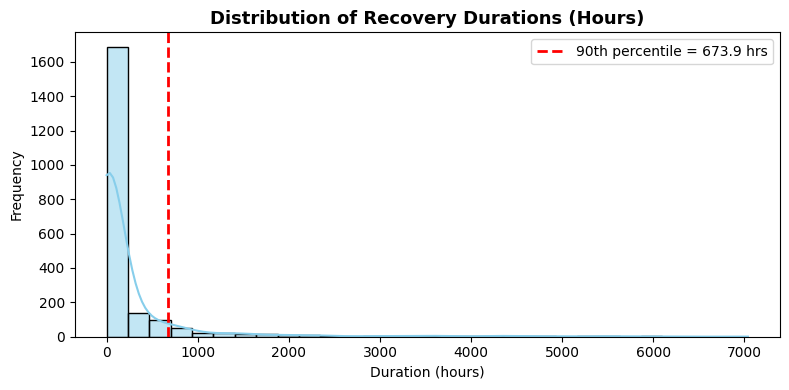

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure duration_hours column exists
seq_df['start_ts'] = pd.to_datetime(seq_df['start_ts'], utc=True, errors='coerce')
seq_df['end_ts']   = pd.to_datetime(seq_df['end_ts'], utc=True, errors='coerce')
seq_df['duration_hours'] = (seq_df['end_ts'] - seq_df['start_ts']).dt.total_seconds() / 3600

# Filter valid durations
durations = seq_df.loc[seq_df['duration_hours'] > 0, 'duration_hours']

# Calculate 90th percentile
p90 = durations.quantile(0.90)

# --- Histogram ---
plt.figure(figsize=(8, 4))
sns.histplot(durations, bins=30, kde=True, color='skyblue')

# Add the 90th percentile line
plt.axvline(p90, color='red', linestyle='--', linewidth=2, label=f"90th percentile = {p90:.1f} hrs")

# Add title and labels
plt.title("Distribution of Recovery Durations (Hours)", fontsize=13, weight='bold')
plt.xlabel("Duration (hours)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


As we can see above, 90% of recovered carts are done so within 673.9 hours, or 28 days. Just under 1 month. Let's see what percentage of the dataset the largest bin is, and what percentile of recovered carts it covers. The distribution looks quite skewed. 

Total observations: 2,123
Number of observations in first bin: 1,687 (79.46% of total)
Duration range of first bin: 0.00 to 234.61 hours


C:\Users\cyrus.sobhani\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


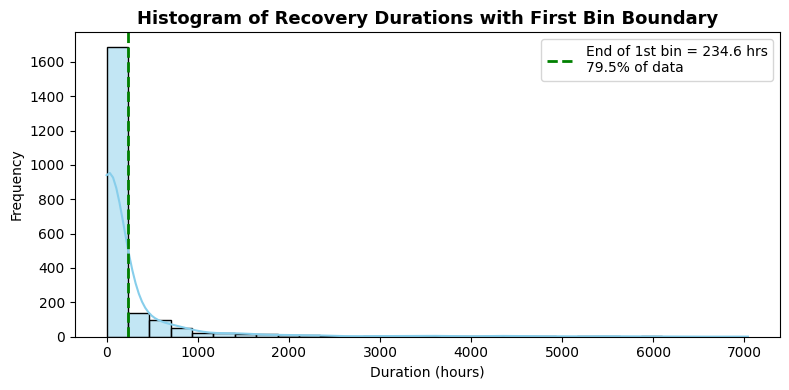

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming durations is already defined
durations = seq_df.loc[seq_df['duration_hours'] > 0, 'duration_hours']

# --- Recreate histogram to get bin edges and counts ---
counts, bin_edges = np.histogram(durations, bins=30)

# --- 1) Extract first bin stats ---
first_bin_count = int(counts[0])
first_bin_start = bin_edges[0]
first_bin_end   = bin_edges[1]
first_bin_range = (first_bin_start, first_bin_end)

# --- 2) Compute percentage ---
total_obs = int(counts.sum())
first_bin_pct = (first_bin_count / total_obs * 100) if total_obs else 0.0

# --- 3) Print results ---
print(f"Total observations: {total_obs:,}")
print(f"Number of observations in first bin: {first_bin_count:,} "
      f"({first_bin_pct:.2f}% of total)")
print(f"Duration range of first bin: {first_bin_range[0]:.2f} to {first_bin_range[1]:.2f} hours")

# --- 4) Optional visualization ---
plt.figure(figsize=(8,4))
sns.histplot(durations, bins=30, kde=True, color='skyblue')
plt.axvline(first_bin_end, color='green', linestyle='--', linewidth=2,
            label=(f"End of 1st bin = {first_bin_end:.1f} hrs\n"
                   f"{first_bin_pct:.1f}% of data"))
plt.title("Histogram of Recovery Durations with First Bin Boundary", fontsize=13, weight='bold')
plt.xlabel("Duration (hours)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


50% of carts are recovered in 2 hours.
75% of carts are recovered in 168 hours, or 7 days.
80% of carts are recovered in 235 hours, or 10 days.
90% of carts are recovered in 674 hours, or 28 days. 

clearly, cart recovery decreases drastically over time from the date of abandonment. Let's visualize cart recovery over time. 

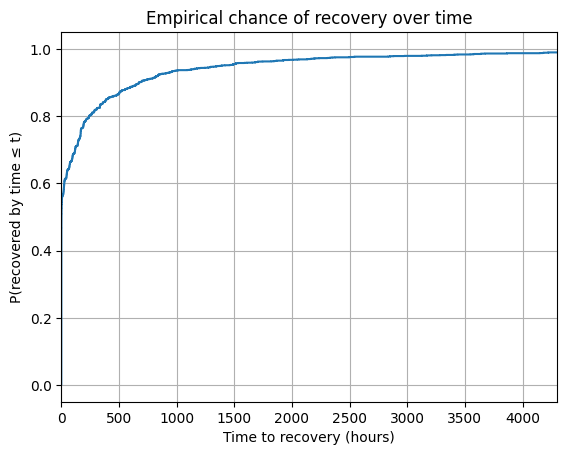

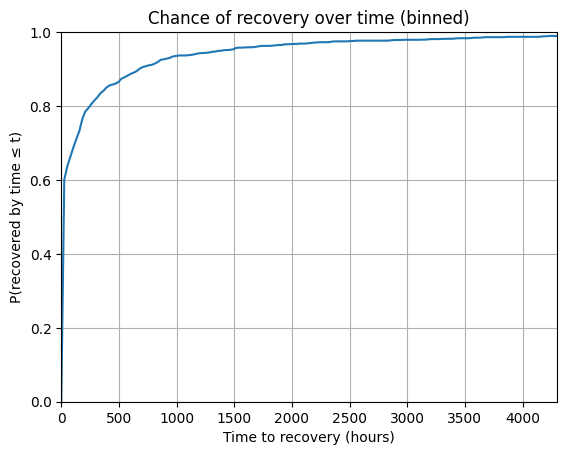

,P(recovered by ≤ t)
1h,0.470561
6h,0.554404
12h,0.563354
24h,0.592558
48h,0.629298
72h,0.653792


In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Assumes seq_df already has duration computed as in your snippet ---
dur = seq_df['duration_hours'].dropna().to_numpy()
dur = dur[dur >= 0]  # guard against negatives

# Percentile cap for readability
p99 = np.percentile(dur, 99) if dur.size else 0.0
xmax = p99 if np.isfinite(p99) and p99 > 0 else (dur.max() if dur.size else 1.0)

# ===== 1) ECDF: P(recovered within ≤ t) =====
x = np.sort(dur)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure()
plt.step(x, y, where="post")
plt.xlim(0, xmax)
plt.xlabel("Time to recovery (hours)")
plt.ylabel("P(recovered by time ≤ t)")
plt.title("Empirical chance of recovery over time")
plt.grid(True)
plt.show()

# ===== 2) Binned curve (optional, smoother) =====
# Choose bin width (e.g., 1 hour) or adaptive by Freedman–Diaconis
if len(dur) >= 2:
    iqr = np.subtract(*np.percentile(dur, [75, 25]))
    bin_width = 2 * iqr / (len(dur) ** (1/3)) if iqr > 0 else max(1.0, np.std(dur) / 5)
    bin_width = max(bin_width, 0.25)  # floor at 15 minutes
else:
    bin_width = 1.0

bins = np.arange(0, xmax + bin_width, bin_width)
cdf_vals = [(dur <= t).mean() for t in bins]

plt.figure()
plt.plot(bins, cdf_vals, marker="")
plt.xlim(0, xmax)
plt.ylim(0, 1)
plt.xlabel("Time to recovery (hours)")
plt.ylabel("P(recovered by time ≤ t)")
plt.title("Chance of recovery over time (binned)")
plt.grid(True)
plt.show()

# ===== 3) Quick landmarks =====
landmarks = [1, 6, 12, 24, 48, 72]
landmark_probs = {f"{h}h": float((dur <= h).mean()) for h in landmarks}
pd.Series(landmark_probs, name="P(recovered by ≤ t)").to_frame()


We can see very clearly that there is a steep chance of prolongued abandonment over time. We should target customers within 72 hours of abandonemnt. 

Now, let's look at what was happening during the abandonment stage. What sort of insights can we glean during this time.

In [146]:
import pandas as pd
from collections import Counter

# --- helpers ---
def top_counts(series, top_n=15):
    s = series.value_counts(dropna=False)
    total = int(s.sum())
    s = s.head(top_n)
    return pd.DataFrame({
        "pattern": s.index.to_list(),
        "count": s.values,
        "percent": (s.values / total * 100) if total else [0.0]*len(s)
    })

def stream_ngrams_count(seqs, n):
    c = Counter()
    for seq in seqs:
        if isinstance(seq, list) and len(seq) >= n:
            c.update(tuple(seq[i:i+n]) for i in range(len(seq)-n+1))
    return c

def top_ngrams_df(seqs, n=2, top_n=15):
    c = stream_ngrams_count(seqs, n)
    total = sum(c.values())
    rows = [(k, v, (v/total*100 if total else 0.0)) for k, v in c.most_common(top_n)]
    return pd.DataFrame(rows, columns=["pattern","count","percent"])

# --- focus ONLY on recovered segments ---
if 'group_status' in seq_df.columns:
    mask_rec = seq_df['group_status'].astype(str).str.lower().eq('recovered')
elif 'recovered' in seq_df.columns:
    mask_rec = seq_df['recovered'].astype(str).str.lower().eq('recovered')
else:
    raise KeyError("seq_df needs a 'group_status' or 'recovered' column to identify recovered segments.")

seqs_rec = seq_df.loc[mask_rec, 'sequence']

# 1) first / last events (vectorized)
first_rec = top_counts(seqs_rec.str[0], top_n=15)
last_rec  = top_counts(seqs_rec.str[-1], top_n=15)

# 2) full sequences (exact)
full_rec = top_counts(
    seqs_rec.map(lambda s: tuple(s) if isinstance(s, list) else ()),
    top_n=10
)

# 3) bigrams / trigrams (streamed)
bigrams_rec  = top_ngrams_df(seqs_rec, n=2, top_n=15)
trigrams_rec = top_ngrams_df(seqs_rec, n=3, top_n=15)

# --- quick peek ---
print("\nTop FIRST events (recovered only):")
display(first_rec.head(15))

print("\nTop LAST events (recovered only):")
display(last_rec.head(15))

print("\nTop FULL sequences (recovered only):")
display(full_rec.head(10))

print("\nTop BIGRAMS (recovered only):")
display(bigrams_rec.head(15))

print("\nTop TRIGRAMS (recovered only):")
display(trigrams_rec.head(15))



Top FIRST events (recovered only):


,pattern,count,percent
0,page_view,1768,83.278380
1,session_start,220,10.362694
2,button_click,61,2.873293
3,nav_link_click,20,0.942063
4,view_item_list,14,0.659444
5,first_visit,12,0.565238
6,login,11,0.518135
7,view_promotion,4,0.188413
8,update_cart,3,0.141309
9,select_promotion,3,0.141309



Top LAST events (recovered only):


,pattern,count,percent
0,purchase,1954,92.039567
1,page_view,93,4.380593
2,ordersuccesspage_displayed,74,3.485634
3,update_cart,1,0.047103
4,session_start,1,0.047103



Top FULL sequences (recovered only):


,pattern,count,percent
0,"(page_view, nav_link_click, page_view, page_vi...",1,0.047103
1,"(page_view, page_view, page_view, button_click...",1,0.047103
2,"(page_view, page_view, page_view, page_view, p...",1,0.047103
3,"(page_view, page_view, page_view, button_click...",1,0.047103
4,"(button_click, page_view, page_view, button_cl...",1,0.047103
5,"(page_view, page_view, page_view, page_view, n...",1,0.047103
6,"(page_view, page_view, page_view, button_click...",1,0.047103
7,"(page_view, button_click, page_view, page_view...",1,0.047103
8,"(button_click, page_view, button_click, button...",1,0.047103
9,"(page_view, page_view, page_view, page_view, p...",1,0.047103



Top BIGRAMS (recovered only):


,pattern,count,percent
0,"(page_view, page_view)",32309,12.639218
1,"(button_click, button_click)",16607,6.496626
2,"(view_item_list, view_item_list)",15674,6.131638
3,"(view_item_list, button_click)",10744,4.203032
4,"(button_click, page_view)",10575,4.136919
5,"(button_click, view_item_list)",9279,3.629927
6,"(page_view, button_click)",8615,3.370171
7,"(page_view, update_cart)",7922,3.099071
8,"(page_view, view_item_list)",6886,2.693790
9,"(view_item_list, page_view)",5890,2.304156



Top TRIGRAMS (recovered only):


,pattern,count,percent
0,"(page_view, page_view, page_view)",14005,5.524611
1,"(button_click, button_click, button_click)",9211,3.633502
2,"(view_item_list, view_item_list, view_item_list)",6319,2.492683
3,"(button_click, page_view, page_view)",5815,2.293868
4,"(page_view, page_view, button_click)",4732,1.866652
5,"(view_item_list, view_item_list, button_click)",4453,1.756594
6,"(page_view, page_view, update_cart)",4370,1.723852
7,"(page_view, button_click, page_view)",3725,1.469416
8,"(view_item_list, button_click, view_item_list)",3626,1.430363
9,"(page_view, view_item_list, view_item_list)",3492,1.377504


As we can see from the sequence mining above, there isn't much insight we can gather. the results are similar in value as the abandonment results. The last event is purchase, which makes sense obviously. We should focus on understanding time as a factor for cart recovery. It appears that the steep drop off in reovery over time shows that abandonment is intentional. Customers either return to their carts, or they move on and wait until they need inventory. 

## Device rate Correlation

Let's look at device correlation by category

### device_category

In [147]:
def visualizecorrelations(ratios,title):
    ratios.plot(kind='bar', color='skyblue')
    plt.title(title)
    plt.xlabel('Category')
    plt.ylabel('Ratio')
    plt.ylim(0, 1)  # since ratios are between 0 and 1
    plt.show()

In [148]:
GARecovered = GoogleAnalytics[((GoogleAnalytics['recovered'] == 'recovered'))]
GAAbandoned = GoogleAnalytics[((GoogleAnalytics['abandoned'] == True))]

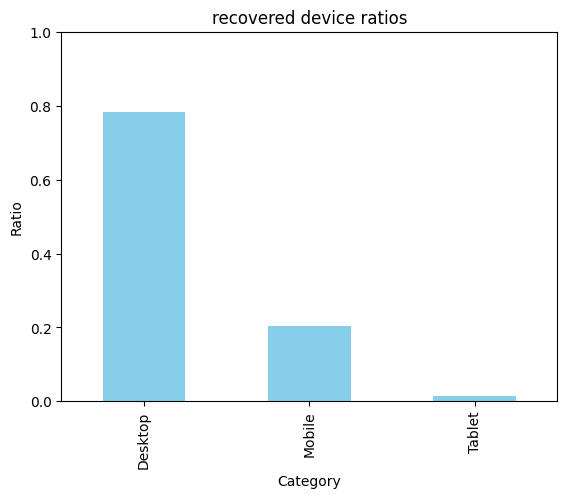

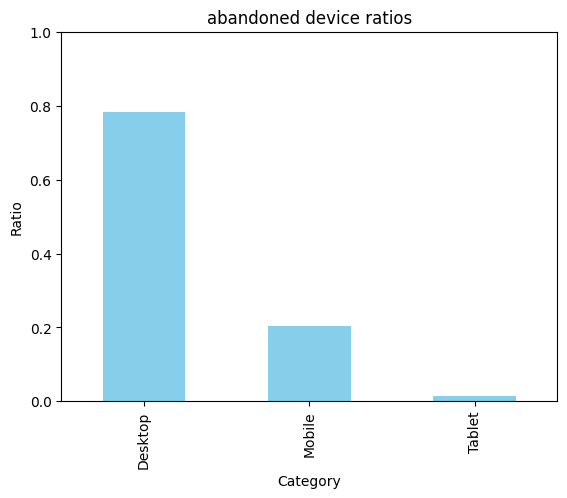

In [149]:
Recoveredratios = GARecovered['device_category'].value_counts(normalize=True)
visualizecorrelations(Recoveredratios,'recovered device ratios')
Abandonedratios = GAAbandoned['device_category'].value_counts(normalize=True)
visualizecorrelations(Recoveredratios,'abandoned device ratios')

Ratio is identical for device_category

### device_mobile_brand_name

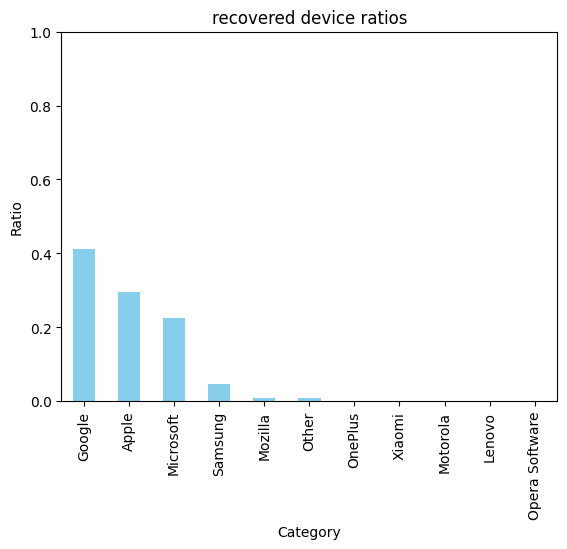

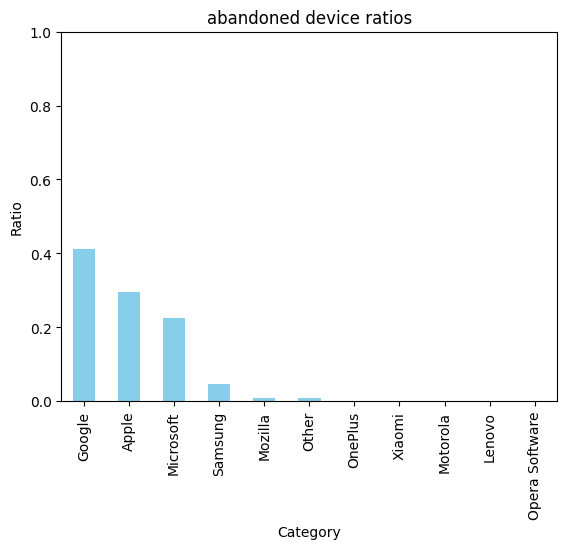

In [150]:
Recoveredratios = GARecovered['device_mobile_brand_name'].value_counts(normalize=True)
visualizecorrelations(Recoveredratios,'recovered device ratios')
Abandonedratios = GAAbandoned['device_mobile_brand_name'].value_counts(normalize=True)
visualizecorrelations(Recoveredratios,'abandoned device ratios')

Ratios are again, identical.

### device_operating_system

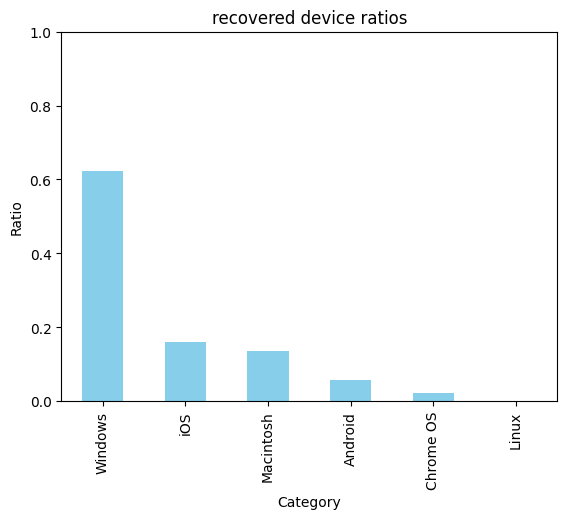

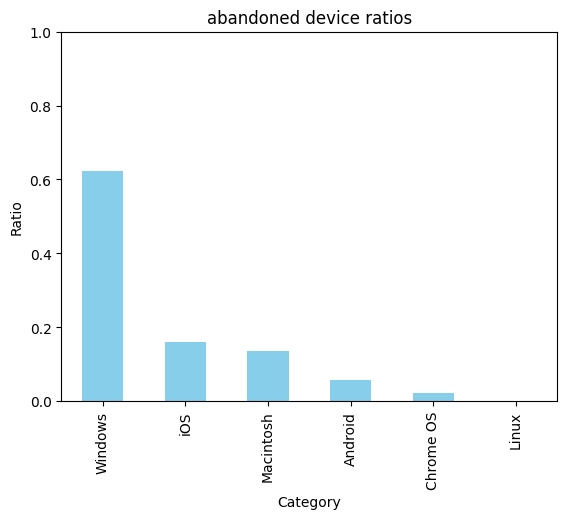

In [151]:
Recoveredratios = GARecovered['device_operating_system'].value_counts(normalize=True)
visualizecorrelations(Recoveredratios,'recovered device ratios')
Abandonedratios = GAAbandoned['device_operating_system'].value_counts(normalize=True)
visualizecorrelations(Recoveredratios,'abandoned device ratios')

Again, completely identical. User behavor does not vary by device type